# 12 — Apify ImmoScout24 Data Pipeline
## MietOptimal / RentSignal

**Input:** `data/raw/scraping/dataset_immobilienscout24-scraper_*.json`  
**Output:** `data/processed/apify_listings_clean.parquet`

### Pipeline
1. Load raw Apify JSON
2. Extract `adTargetingParameters` (primary, English values)
3. Extract thermalChar + yearConstructed fallback from `sections`
4. Type conversions (y/n → bool, strings → float)
5. Derive rent_sqm, sqm_per_room, building_era, bezirk
6. Filter outliers
7. Schema validation vs listings_clean.parquet
8. Save parquet + lineage hash


In [2]:
import json, hashlib, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR  = Path('../data/raw/scraping')
PROC_DIR = Path('../data/processed')
OUT_FILE = PROC_DIR / 'apify_listings_clean.parquet'

files = sorted(RAW_DIR.glob('dataset_immobilienscout24*.json'))
assert files, f'No scrape files found in {RAW_DIR}'
RAW_FILE = files[-1]
print('Loading:', RAW_FILE.name)

Loading: dataset_immobilienscout24-scraper_2026-03-17_22-19-02-037.json


## 1. Load Raw JSON

In [3]:
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)

print(f'Records loaded: {len(raw):,}')
print('Top-level keys:', list(raw[0].keys()))

Records loaded: 568
Top-level keys: ['header', 'sections', 'contact', 'tracking', 'adTargetingParameters', 'basicInfo', 'scrapedAt', 'url']


## 2. Extract adTargetingParameters

Primary source: flat dict per listing with English field names.  
Coverage from test run (n=568): baseRent/livingSpace/noRooms/all binaries/condition/interiorQual/typeOfFlat/zipCode = **100%**  
firingTypes (heatingType proxy) = 97% | yearConstructed = 41% | numberOfFloors = 47%


In [4]:
def extract_atp(rec):
    atp  = rec.get('adTargetingParameters', {})
    addr = rec.get('basicInfo', {}).get('address', {})
    return {
        'scoutId':        str(atp.get('obj_scoutId', '')),
        'scrapedAt':      rec.get('scrapedAt', ''),
        'baseRent':       atp.get('obj_baseRent'),
        'totalRent':      atp.get('obj_totalRent'),
        'serviceCharge':  atp.get('obj_serviceCharge'),
        'heatingCosts':   atp.get('obj_heatingCosts'),
        'livingSpace':    atp.get('obj_livingSpace'),
        'noRooms':        atp.get('obj_noRooms'),
        'yearConstructed':atp.get('obj_yearConstructed'),
        'floor':          atp.get('obj_floor'),
        'numberOfFloors': atp.get('obj_numberOfFloors'),
        'balcony':        atp.get('obj_balcony'),
        'hasKitchen':     atp.get('obj_hasKitchen'),
        'lift':           atp.get('obj_lift'),
        'cellar':         atp.get('obj_cellar'),
        'garden':         atp.get('obj_garden'),
        'newlyConst':     atp.get('obj_newlyConst'),
        'condition':      atp.get('obj_condition'),
        'interiorQual':   atp.get('obj_interiorQual'),
        'typeOfFlat':     atp.get('obj_typeOfFlat'),
        # firingTypes has 97% coverage vs heatingType 48%
        'heatingType':    atp.get('obj_firingTypes') or atp.get('obj_heatingType'),
        'plz':            str(atp.get('obj_zipCode', '')),
        'bezirk_raw':     atp.get('obj_regio3', ''),
        'neighborhood':   atp.get('obj_regio4', atp.get('geo_ot', '')),
        'lat':            addr.get('lat'),
        'lon':            addr.get('lon'),
        'immotype':       atp.get('obj_immotype', ''),
    }

df = pd.DataFrame([extract_atp(r) for r in raw])
print(f'Extracted: {df.shape}')
df.head(3)

Extracted: (568, 27)


,scoutId,scrapedAt,baseRent,totalRent,serviceCharge,heatingCosts,livingSpace,noRooms,yearConstructed,floor,...,condition,interiorQual,typeOfFlat,heatingType,plz,bezirk_raw,neighborhood,lat,lon,immotype
0,166376503,2026-03-17T22:18:34.481Z,880,1040,94,66,55.14,2,2020,3,...,well_kept,no_information,apartment,gas,12439,Treptow_Köpenick,Niederschöneweide,52.45425,13.51678,wohnung_miete
1,166377363,2026-03-17T22:18:34.496Z,1790,1990,200,NaN,94,4,NaN,3,...,fully_renovated,sophisticated,apartment,no_information,13349,Mitte_Bezirk,Wedding,52.56285,13.34220,wohnung_miete
2,166375399,2026-03-17T22:18:34.500Z,674.45,1014.45,220,120,75.51,2.5,1974,2,...,well_kept,normal,other,combined_heat_and_power_fossil_fuels,12057,Neukölln_Bezirk,Neukölln_Ortsteil,52.47665,13.46601,wohnung_miete


## 3. Extract from sections

Section `Bausubstanz & Energieausweis`:  
- `Baujahr:` → yearConstructed fallback  
- `Energieverbrauchskennwert:` / `Endenergiebedarf:` → thermalChar (kWh/m²)


In [5]:
ENERGY_SECTIONS = {'Bausubstanz & Energieausweis', 'Building details & energy certificate'}
THERMAL_LABELS  = {'energieverbrauchskennwert', 'endenergiebedarf', 'endenergieverbrauch',
                   'energy consumption', 'primary energy demand'}
YEAR_LABELS     = {'baujahr', 'year of construction'}

def extract_sections(rec):
    thermal, year_fb = None, None
    for s in rec.get('sections', []):
        if not isinstance(s, dict) or s.get('title') not in ENERGY_SECTIONS:
            continue
        for attr in s.get('attributes', []):
            label = str(attr.get('label', '')).lower().strip().rstrip(':')
            text  = str(attr.get('text',  '')).strip()
            if not text or text.lower() in ('no information', 'keine angabe', ''):
                continue
            if label in THERMAL_LABELS:
                m = re.search(r'[\d.,]+', text)
                if m:
                    try: thermal = float(m.group().replace(',', '.'))
                    except ValueError: pass
            if label in YEAR_LABELS:
                m = re.search(r'\d{4}', text)
                if m:
                    try: year_fb = float(m.group())
                    except ValueError: pass
    return {'thermalChar': thermal, 'year_from_sections': year_fb}

sec_df = pd.DataFrame([extract_sections(r) for r in raw])
print('thermalChar found:       ', sec_df['thermalChar'].notna().sum(), '/', len(sec_df))
print('year_from_sections found:', sec_df['year_from_sections'].notna().sum(), '/', len(sec_df))

thermalChar found:        151 / 568
year_from_sections found: 235 / 568


In [6]:
df = pd.concat([df, sec_df], axis=1)

df['yearConstructed']    = pd.to_numeric(df['yearConstructed'],    errors='coerce')
df['year_from_sections'] = pd.to_numeric(df['year_from_sections'], errors='coerce')
df['yearConstructed']    = df['yearConstructed'].fillna(df['year_from_sections'])
df.drop(columns=['year_from_sections'], inplace=True)

print(f'yearConstructed fill rate: {df["yearConstructed"].notna().mean():.1%}')
print(f'thermalChar fill rate:     {df["thermalChar"].notna().mean():.1%}')

yearConstructed fill rate: 41.4%
thermalChar fill rate:     26.6%


## 4. Type Conversions

In [7]:
for col in ['baseRent','totalRent','serviceCharge','heatingCosts',
            'livingSpace','noRooms','floor','numberOfFloors','thermalChar']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

BINARY = ['balcony','hasKitchen','lift','cellar','garden','newlyConst']
for col in BINARY:
    df[col] = df[col].map({'y': True, 'n': False, 'j': True})

for col in ['condition','interiorQual','typeOfFlat','heatingType']:
    df[col] = (df[col].fillna('unknown').str.lower().str.strip()
                      .replace({'no_information': 'unknown', 'keine angabe': 'unknown', '': 'unknown'}))

print('Done.')

Done.


## 5. Derive Features

In [8]:
df['rent_sqm']     = df['baseRent'] / df['livingSpace']
df['sqm_per_room'] = df['livingSpace'] / df['noRooms'].clip(lower=1)
df['date']         = pd.to_datetime(df['scrapedAt'], errors='coerce').dt.strftime('%b%y')

def clean_bezirk(raw):
    if not raw: return 'unknown'
    s = re.sub(r'_?bezirk', '', str(raw), flags=re.IGNORECASE).replace('_', ' ').strip()
    fixes = {
        'Treptow K penick':     'Treptow - Koepenick',
        'Tempelhof Sch neberg': 'Tempelhof - Schoeneberg',
        'Steglitz Zehlendorf':  'Steglitz - Zehlendorf',
        'Marzahn Hellersdorf':  'Marzahn - Hellersdorf',
    }
    for bad, good in fixes.items():
        if bad.lower() in s.lower(): return good
    return s

df['bezirk'] = df['bezirk_raw'].apply(clean_bezirk)

def building_era(y):
    if pd.isna(y): return 'unknown'
    y = int(y)
    if y < 1900: return 'pre_1900'
    if y < 1919: return 'wilhelminian'
    if y < 1933: return 'weimar'
    if y < 1946: return 'nazi_postwar'
    if y < 1961: return 'postwar'
    if y < 1976: return 'economic_miracle'
    if y < 1991: return 'modern'
    if y < 2001: return 'reunification'
    if y < 2011: return 'contemporary'
    return 'new_build'

df['building_era'] = df['yearConstructed'].apply(building_era)
print('rent_sqm:', round(df['rent_sqm'].min(),2), '-', round(df['rent_sqm'].max(),2))
print(df['building_era'].value_counts())

rent_sqm: 4.16 - 49.55
building_era
unknown             333
new_build           108
wilhelminian         40
economic_miracle     22
reunification        18
postwar              15
modern                9
pre_1900              9
weimar                6
contemporary          5
nazi_postwar          3
Name: count, dtype: int64


## 6. Filter Outliers

In [9]:
n0 = len(df)
df = df[df['baseRent'].notna() & df['livingSpace'].notna() & df['noRooms'].notna()]
df = df[df['plz'].str.len() == 5]
df = df[df['immotype'].isin({'wohnung_miete', ''})]
df = df[(df['rent_sqm'] >= 3) & (df['rent_sqm'] <= 50)]
df = df[(df['livingSpace'] >= 10) & (df['livingSpace'] <= 500)]
df = df[(df['noRooms'] >= 0.5) & (df['noRooms'] <= 20)]
df['floor'] = df['floor'].clip(lower=0, upper=50)
mask = df['yearConstructed'].notna()
df.loc[mask, 'yearConstructed'] = df.loc[mask, 'yearConstructed'].clip(1850, 2026)
print(f'Before: {n0}  After: {len(df)}  Dropped: {n0 - len(df)}')

Before: 568  After: 568  Dropped: 0


## 7. Final Schema

In [10]:
FINAL_COLS = [
    'scoutId', 'date',
    'baseRent', 'totalRent', 'serviceCharge',
    'rent_sqm', 'livingSpace', 'noRooms',
    'yearConstructed', 'floor', 'numberOfFloors', 'thermalChar',
    'sqm_per_room',
    'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst',
    'condition', 'interiorQual', 'typeOfFlat', 'heatingType',
    'building_era', 'bezirk', 'neighborhood', 'plz',
]

df_out = df[FINAL_COLS].copy()

BINARY = ['balcony','hasKitchen','lift','cellar','garden','newlyConst']
for col in BINARY:
    df_out[col] = df_out[col].fillna(False).astype(bool)

STR_COLS = ['scoutId','date','condition','interiorQual','typeOfFlat',
            'heatingType','building_era','bezirk','neighborhood','plz']
for col in STR_COLS:
    df_out[col] = df_out[col].fillna('unknown').astype(str)

print(f'Final shape: {df_out.shape}')
print(df_out.dtypes.to_string())
missing = df_out.isnull().sum()
print('Missing:', missing[missing > 0].to_dict())

Final shape: (568, 27)
scoutId                str
date                   str
baseRent           float64
totalRent          float64
serviceCharge      float64
rent_sqm           float64
livingSpace        float64
noRooms            float64
yearConstructed    float64
floor              float64
numberOfFloors     float64
thermalChar        float64
sqm_per_room       float64
balcony               bool
hasKitchen            bool
lift                  bool
cellar                bool
garden                bool
newlyConst            bool
condition              str
interiorQual           str
typeOfFlat             str
heatingType            str
building_era           str
bezirk                 str
neighborhood           str
plz                    str
Missing: {'totalRent': 113, 'serviceCharge': 111, 'yearConstructed': 333, 'floor': 111, 'numberOfFloors': 299, 'thermalChar': 417}


## 8. EDA

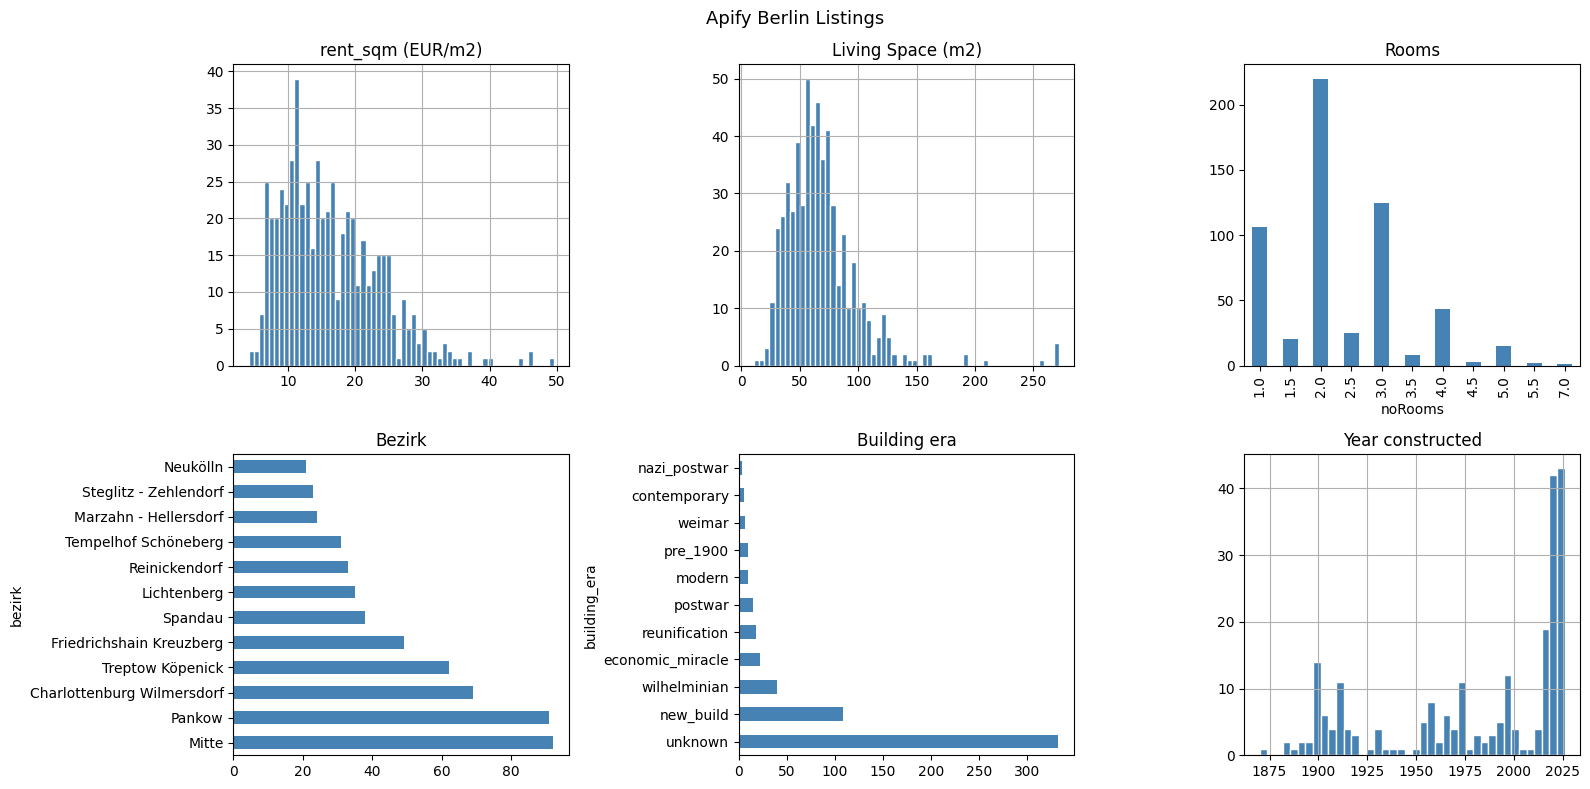

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
df_out['rent_sqm'].hist(bins=60, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('rent_sqm (EUR/m2)')
df_out['livingSpace'].hist(bins=60, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Living Space (m2)')
df_out['noRooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Rooms')
df_out['bezirk'].value_counts().plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Bezirk')
df_out['building_era'].value_counts().plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Building era')
df_out['yearConstructed'].hist(bins=40, ax=axes[1,2], color='steelblue', edgecolor='white')
axes[1,2].set_title('Year constructed')
plt.suptitle('Apify Berlin Listings', fontsize=13)
plt.tight_layout()
plt.show()

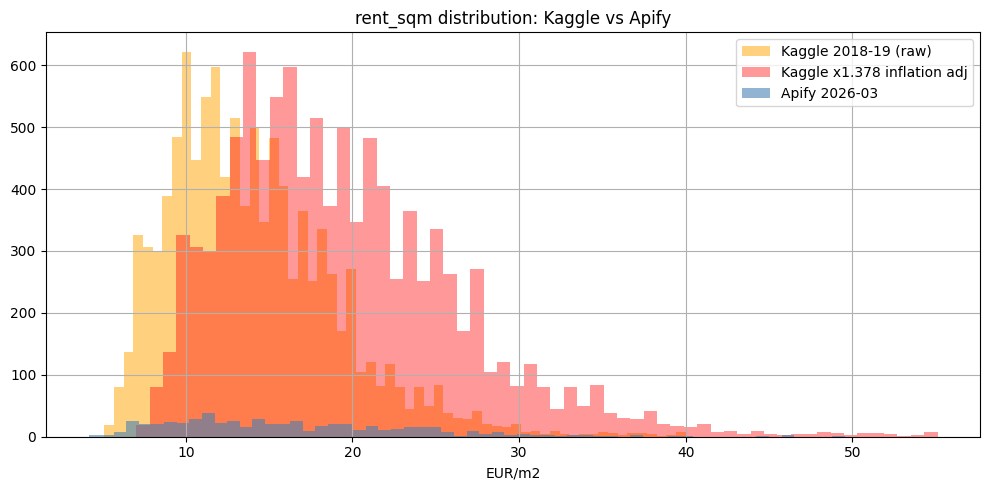

Kaggle mean (raw):      14.06
Kaggle mean (x1.378):   19.37
Apify  mean:            16.26

If Apify mean is close to Kaggle x1.378 -> inflation adjustment was correct
If Apify mean differs significantly -> update inflation_factor in model_config.json


In [12]:
# KEY CHECK: Does Apify rent level match inflation-adjusted Kaggle?
kaggle = pd.read_parquet('../data/processed/listings_clean.parquet')

fig, ax = plt.subplots(figsize=(10, 5))
kaggle['rent_sqm'].hist(bins=60, alpha=0.5, label='Kaggle 2018-19 (raw)', color='orange', ax=ax)
(kaggle['rent_sqm'] * 1.378).hist(bins=60, alpha=0.4, label='Kaggle x1.378 inflation adj', color='red', ax=ax)
df_out['rent_sqm'].hist(bins=60, alpha=0.6, label='Apify 2026-03', color='steelblue', ax=ax)
ax.set_xlabel('EUR/m2')
ax.set_title('rent_sqm distribution: Kaggle vs Apify')
ax.legend()
plt.tight_layout()
plt.show()

print('Kaggle mean (raw):     ', round(kaggle['rent_sqm'].mean(), 2))
print('Kaggle mean (x1.378):  ', round(kaggle['rent_sqm'].mean() * 1.378, 2))
print('Apify  mean:           ', round(df_out['rent_sqm'].mean(), 2))
print()
print('If Apify mean is close to Kaggle x1.378 -> inflation adjustment was correct')
print('If Apify mean differs significantly -> update inflation_factor in model_config.json')

In [13]:
features = ['livingSpace','noRooms','yearConstructed','floor','numberOfFloors',
            'thermalChar','balcony','hasKitchen','lift','cellar','garden',
            'newlyConst','condition','interiorQual','typeOfFlat','heatingType',
            'building_era','bezirk','plz']
print('Feature coverage:')
for col in features:
    if df_out[col].dtype == bool:
        pct = 100.0
    elif df_out[col].dtype == object:
        pct = (df_out[col] != 'unknown').mean() * 100
    else:
        pct = df_out[col].notna().mean() * 100
    status = 'OK  ' if pct > 80 else 'WARN' if pct > 40 else 'LOW '
    print(f'  [{status}] {col:<20} {pct:.0f}%')

Feature coverage:
  [OK  ] livingSpace          100%
  [OK  ] noRooms              100%
  [WARN] yearConstructed      41%
  [OK  ] floor                80%
  [WARN] numberOfFloors       47%
  [LOW ] thermalChar          27%
  [OK  ] balcony              100%
  [OK  ] hasKitchen           100%
  [OK  ] lift                 100%
  [OK  ] cellar               100%
  [OK  ] garden               100%
  [OK  ] newlyConst           100%
  [OK  ] condition            100%
  [OK  ] interiorQual         100%
  [OK  ] typeOfFlat           100%
  [OK  ] heatingType          100%
  [OK  ] building_era         100%
  [OK  ] bezirk               100%
  [OK  ] plz                  100%


## 9. Save + Lineage

In [14]:
df_out.to_parquet(OUT_FILE, index=False)

sha256 = hashlib.sha256(open(OUT_FILE, 'rb').read()).hexdigest()
scrape_month = pd.Timestamp.now().strftime('%Y-%m')

print('Saved:', OUT_FILE)
print('Rows: ', len(df_out))
print('SHA-256:', sha256)
print()
print('--- Paste into model_config.json when retraining ---')
print('data_source:             apify_immoscout24_berlin_' + scrape_month)
print('data_file:               data/processed/apify_listings_clean.parquet')
print('data_file_sha256:        ' + sha256)
print('inflation_factor_active: false')

Saved: ..\data\processed\apify_listings_clean.parquet
Rows:  568
SHA-256: 93440aeda86b66de3617cd7d84255c2392f6107b548d703bf5604a85555db2c6

--- Paste into model_config.json when retraining ---
data_source:             apify_immoscout24_berlin_2026-03
data_file:               data/processed/apify_listings_clean.parquet
data_file_sha256:        93440aeda86b66de3617cd7d84255c2392f6107b548d703bf5604a85555db2c6
inflation_factor_active: false


## Next Steps
1. **Add spatial features** — run notebooks 03a + 03b on `apify_listings_clean.parquet` → `apify_listings_with_spatial.parquet`
2. **Retrain** — run notebook 04, set `inflation_factor_active: false` → v4.0.0 artifacts
3. **Regenerate SHAP** immediately after retraining (see ML-TRAINING-WORKFLOW.md §7)
4. **Update model_config.json** with SHA-256 and version printed above
